# `mumfordshah2d` — release smoke test

Exercises the 2-D L2 Mumford-Shah ADMM driver on small synthetic images. Useful as both:

- A post-publish check after `pip install mumfordshah2d`.
- A first-time-user introduction to the API.

Each section is self-contained. Run-all completes in well under a minute.

## 1. Install and import

In [1]:
# %pip install mumfordshah2d matplotlib --quiet

import numpy as np
import matplotlib.pyplot as plt
import mumfordshah2d as ms

rng = np.random.default_rng(0)

# Verify the Rust extension is loaded.
import mumfordshah2d._core as _core
print('Rust core loaded from:', _core.__file__)
print('package version:', ms.__version__)

Rust core loaded from: /Users/storath_fhws/Documents/__INBOX/2026-05-06_GitMaintenanceDevContainer/devcontainer/10-OwnRepos/MumfordShah2D/mumfordshah2d/_core.cpython-312-aarch64-linux-gnu.so
package version: 0.2.0


## 2. 4-connected vs 8-connected on a binary cross

The 4-connected (anisotropic) variant treats horizontal and vertical neighbours equally; the 8-connected (near-isotropic) variant adds the two diagonal directions with the MATLAB-default `√2-1` and `1-√2/2` weights.

On axis-aligned shapes (this cross) both look similar; on rotated edges the 8-connected version is visibly cleaner.

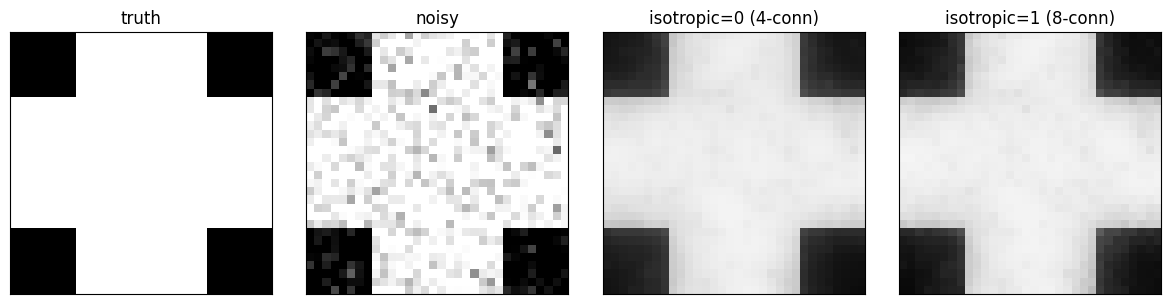

In [2]:
n = 32
img = np.zeros((n, n))
img[n // 4 : 3 * n // 4, :] = 1.0
img[:, n // 4 : 3 * n // 4] = 1.0
noisy = np.clip(img + rng.normal(0, 0.15, size=img.shape), 0, 1)

out_4 = ms.min_l2_mum_2d(noisy, gamma=0.5, alpha=2.0, isotropic=0, max_iter=200)
out_8 = ms.min_l2_mum_2d(noisy, gamma=0.5, alpha=2.0, isotropic=1, max_iter=200)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, im, title in zip(
    axes,
    [img, noisy, out_4, out_8],
    ['truth', 'noisy', 'isotropic=0 (4-conn)', 'isotropic=1 (8-conn)'],
):
    ax.imshow(im, vmin=0, vmax=1, cmap='gray')
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 3. γ controls the jump count

Three γ values on the same noisy image. Small γ allows many discontinuities (close to the input); large γ collapses to fewer, sharper segments.

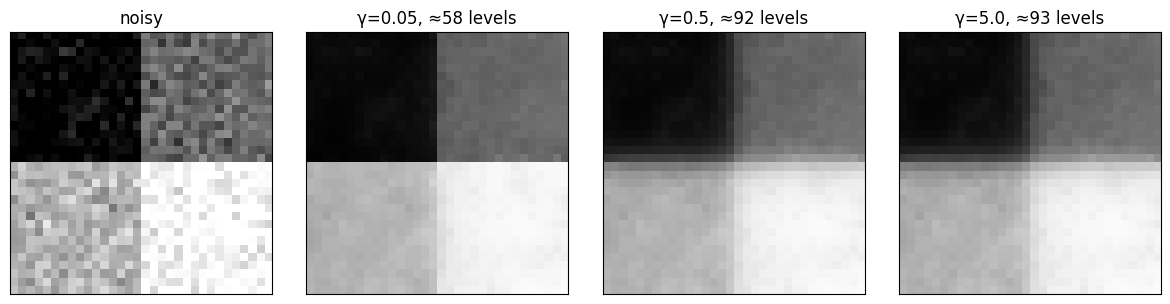

In [3]:
n = 32
truth = np.zeros((n, n))
truth[:n//2, :n//2] = 0.0
truth[:n//2, n//2:] = 0.4
truth[n//2:, :n//2] = 0.7
truth[n//2:, n//2:] = 1.0
noisy = np.clip(truth + rng.normal(0, 0.08, size=truth.shape), 0, 1)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(noisy, vmin=0, vmax=1, cmap='gray')
axes[0].set_title('noisy'); axes[0].set_xticks([]); axes[0].set_yticks([])
for ax, gamma in zip(axes[1:], [0.05, 0.5, 5.0]):
    out = ms.min_l2_mum_2d(noisy, gamma=gamma, alpha=1.0, isotropic=1, max_iter=200)
    n_levels = len(np.unique(out.round(2)))
    ax.imshow(out, vmin=0, vmax=1, cmap='gray')
    ax.set_title(f'γ={gamma}, ≈{n_levels} levels')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 4. Multi-channel (RGB) image

The driver accepts `(rows, cols, channels)` arrays directly; γ and α are shared across channels (joint denoising).

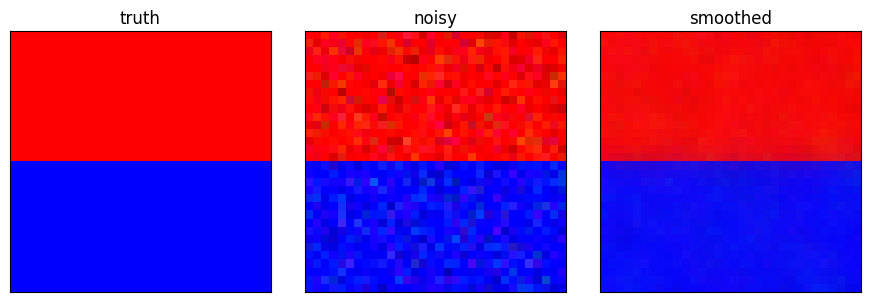

In [4]:
rgb = np.zeros((32, 32, 3))
rgb[:16, :, 0] = 1.0   # top half red
rgb[16:, :, 2] = 1.0   # bottom half blue
rgb_noisy = np.clip(rgb + rng.normal(0, 0.1, size=rgb.shape), 0, 1)
rgb_smoothed = ms.min_l2_mum_2d(rgb_noisy, gamma=0.5, alpha=1.0, isotropic=1, max_iter=200)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, im, title in zip(axes, [rgb, rgb_noisy, rgb_smoothed], ['truth', 'noisy', 'smoothed']):
    ax.imshow(im); ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

assert rgb_smoothed.shape == rgb.shape

## 5. Summary

In [5]:
print(f'mumfordshah2d {ms.__version__} — smoke test OK')

mumfordshah2d 0.2.0 — smoke test OK
